# EDA

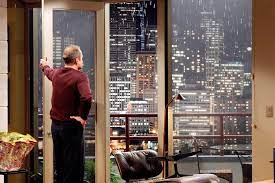

# EDA - King County Housing Market
## Client: Jennifer Montgomery

**Client Profile:**
- High budget (top 10%)
- Must have: Waterfront property
- Timeline: Buy within 1 month, resell within 1 year
- Goal: Maximum resale value & prestige

## Research Questions & Hypotheses
- **H1:** Waterfront properties have significantly higher prices
- **H2a:** Higher grade = higher price
- **H2b:** Medina (98039) is above county average
- **H3a:** More recently renovated = higher price
- **H3b:** Renovated after 2000 > never renovated

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/king_county.csv')

print(df.shape)
df.head()

(21597, 21)


,sale_id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,yr_built,yr_renovated,zipcode,lat,long,sqft_above,sqft_basement,sqft_living15,sqft_lot15
0,1,2014-10-13,221900.000,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,...,7,1955,0.000,98178,47.511,-122.257,1180.000,0.000,1340.000,5650.000
1,2,2014-12-09,538000.000,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,...,7,1951,19910.000,98125,47.721,-122.319,2170.000,400.000,1690.000,7639.000
2,3,2015-02-25,180000.000,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,...,6,1933,NaN,98028,47.738,-122.233,770.000,0.000,2720.000,8062.000
3,4,2014-12-09,604000.000,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,...,7,1965,0.000,98136,47.521,-122.393,1050.000,910.000,1360.000,5000.000
4,5,2015-02-18,510000.000,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,...,8,1987,0.000,98074,47.617,-122.045,1680.000,0.000,1800.000,7503.000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_id        21597 non-null  int64  
 1   date           21597 non-null  object 
 2   price          21597 non-null  float64
 3   bedrooms       21597 non-null  float64
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  float64
 6   sqft_lot       21597 non-null  float64
 7   floors         21597 non-null  float64
 8   waterfront     19206 non-null  float64
 9   view           21534 non-null  float64
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_above     21597 non-null  float64
 18  sqft_b

In [4]:
# Check for duplicates
print(f"Total rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate sale_id: {df['sale_id'].duplicated().sum()}")

Total rows: 21597
Duplicate rows: 0
Duplicate sale_id: 0


In [5]:
df.isnull().sum()

sale_id             0
date                0
price               0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_above          0
sqft_basement     452
sqft_living15       0
sqft_lot15          0
dtype: int64

In [6]:
# Waterfront: missing values filled with 0 (assuming no waterfront access)
df['waterfront'] = df['waterfront'].fillna(0)

# yr_renovated: missing values filled with 0 (assuming never renovated)
df['yr_renovated'] = df['yr_renovated'].fillna(0)

# view: missing values filled with 0 (assuming no view)
df['view'] = df['view'].fillna(0)

# sqft_basement: missing values filled with 0 (assuming no basement)
df['sqft_basement'] = df['sqft_basement'].fillna(0)

# Verify no missing values remain
print(df.isnull().sum().sum(), "missing values remaining")

0 missing values remaining


In [7]:
df['date'].head()

0    2014-10-13
1    2014-12-09
2    2015-02-25
3    2014-12-09
4    2015-02-18
Name: date, dtype: object

In [8]:
# Convert date column to datetime format
df['date'] = pd.to_datetime(df['date'])

# Verify
print(df['date'].dtype)
df['date'].head()

datetime64[ns]


0   2014-10-13
1   2014-12-09
2   2015-02-25
3   2014-12-09
4   2015-02-18
Name: date, dtype: datetime64[ns]

In [9]:
# Check columns relevant to my hypotheses
cols = ['price', 'waterfront', 'zipcode', 'grade', 'yr_renovated']

df[cols].describe()

,price,waterfront,zipcode,grade,yr_renovated
count,21597.000,21597.000,21597.000,21597.000,21597.000
mean,540296.574,0.007,98077.952,7.658,687.582
std,367368.140,0.082,53.513,1.173,3640.375
min,78000.000,0.000,98001.000,3.000,0.000
25%,322000.000,0.000,98033.000,7.000,0.000
50%,450000.000,0.000,98065.000,7.000,0.000
75%,645000.000,0.000,98118.000,8.000,0.000
max,7700000.000,1.000,98199.000,13.000,20150.000


In [10]:
print(df['date'].min())
print(df['date'].max())
print(df['date'].sort_values().head(10))

2014-05-02 00:00:00
2015-05-27 00:00:00
7316    2014-05-02
20586   2014-05-02
1040    2014-05-02
20543   2014-05-02
9587    2014-05-02
9578    2014-05-02
11879   2014-05-02
11895   2014-05-02
4959    2014-05-02
3719    2014-05-02
Name: date, dtype: datetime64[ns]


In [11]:
print(f"Total records: {len(df)}")
print(f"Date range: {df['date'].min().date()} — {df['date'].max().date()}")
print(f"Price range: ${df['price'].min():,.0f} — ${df['price'].max():,.0f}")
print(f"Average price: ${df['price'].mean():,.0f}")
print(f"Unique zipcodes: {df['zipcode'].nunique()}")
print(f"Waterfront properties: {int(df['waterfront'].sum())} ({df['waterfront'].mean()*100:.1f}%)")

Total records: 21597
Date range: 2014-05-02 — 2015-05-27
Price range: $78,000 — $7,700,000
Average price: $540,297
Unique zipcodes: 70
Waterfront properties: 146 (0.7%)


In [12]:
df['grade'].unique()


array([ 7,  6,  8, 11,  9,  5, 10, 12,  4,  3, 13])

In [13]:
# Check all non-zero renovation years
df[df['yr_renovated'] > 0]['yr_renovated'].unique()

array([19910., 20020., 20100., 19920., 20130., 19940., 19780., 20050.,
       20030., 19840., 19540., 20140., 20110., 19830., 19450., 19900.,
       19880., 19770., 19810., 19950., 20000., 19990., 19980., 19700.,
       19890., 20040., 19860., 20070., 19870., 20060., 19850., 20010.,
       19800., 19710., 19790., 19970., 19500., 19690., 19480., 20090.,
       20150., 19740., 20080., 19680., 20120., 19630., 19510., 19620.,
       19530., 19930., 19960., 19550., 19820., 19560., 19400., 19760.,
       19460., 19750., 19640., 19730., 19570., 19590., 19600., 19670.,
       19650., 19340., 19720., 19440., 19580.])

In [14]:
    # Fix yr_renovated: all non-zero values have an extra zero (e.g. 19910 → 1991)
    df.loc[df['yr_renovated'] > 0, 'yr_renovated'] = df.loc[df['yr_renovated'] > 0, 'yr_renovated'] / 10

    # Verify
    print(df[df['yr_renovated'] > 0]['yr_renovated'].unique())

[1991. 2002. 2010. 1992. 2013. 1994. 1978. 2005. 2003. 1984. 1954. 2014.
 2011. 1983. 1945. 1990. 1988. 1977. 1981. 1995. 2000. 1999. 1998. 1970.
 1989. 2004. 1986. 2007. 1987. 2006. 1985. 2001. 1980. 1971. 1979. 1997.
 1950. 1969. 1948. 2009. 2015. 1974. 2008. 1968. 2012. 1963. 1951. 1962.
 1953. 1993. 1996. 1955. 1982. 1956. 1940. 1976. 1946. 1975. 1964. 1973.
 1957. 1959. 1960. 1967. 1965. 1934. 1972. 1944. 1958.]


In [15]:
# Convert yr_renovated to integer
df['yr_renovated'] = df['yr_renovated'].astype(int)

# Verify
print(df['yr_renovated'].dtype)
print(df[df['yr_renovated'] > 0]['yr_renovated'].unique())

int64
[1991 2002 2010 1992 2013 1994 1978 2005 2003 1984 1954 2014 2011 1983
 1945 1990 1988 1977 1981 1995 2000 1999 1998 1970 1989 2004 1986 2007
 1987 2006 1985 2001 1980 1971 1979 1997 1950 1969 1948 2009 2015 1974
 2008 1968 2012 1963 1951 1962 1953 1993 1996 1955 1982 1956 1940 1976
 1946 1975 1964 1973 1957 1959 1960 1967 1965 1934 1972 1944 1958]


## H1: Waterfront vs Price

**Research Question:** Does waterfront location affect house price?

**Hypothesis:** If a house has waterfront access, then the price is 
significantly higher than non-waterfront houses.

**Indicators:** `waterfront`, `price`

In [16]:
# Separate waterfront and non-waterfront
waterfront_prices = df[df['waterfront'] == 1]['price']
non_waterfront_prices = df[df['waterfront'] == 0]['price']

print(f"Waterfront avg price:     ${waterfront_prices.mean():,.0f}")
print(f"Non-waterfront avg price: ${non_waterfront_prices.mean():,.0f}")
print(f"Price premium:            {waterfront_prices.mean() / non_waterfront_prices.mean():.1f}x")

Waterfront avg price:     $1,717,215
Non-waterfront avg price: $532,286
Price premium:            3.2x


In [17]:
# What percentile are waterfront properties in terms of price?
waterfront_avg = df[df['waterfront'] == 1]['price'].mean()
percentile = (df['price'] < waterfront_avg).mean() * 100
print(f"Waterfront avg price is in the top {100 - percentile:.0f}% percentile")

Waterfront avg price is in the top 2% percentile


In [18]:
import os
os.makedirs('images', exist_ok=True)

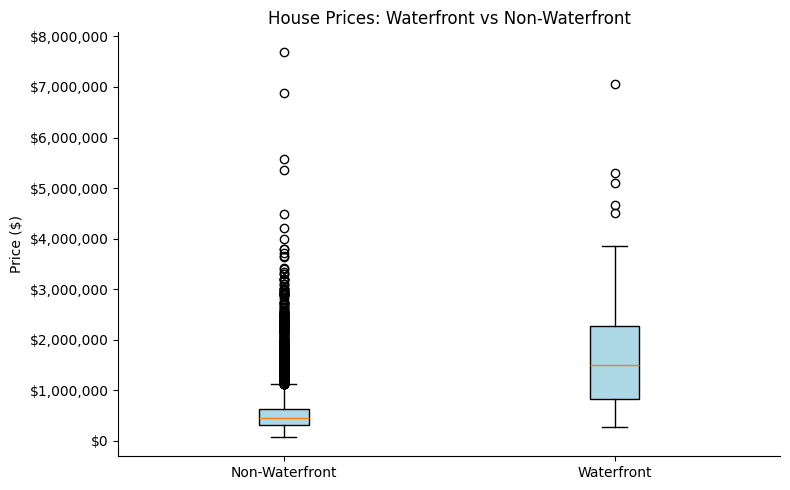

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    [non_waterfront_prices, waterfront_prices],
    labels=['Non-Waterfront', 'Waterfront'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)

ax.set_title('House Prices: Waterfront vs Non-Waterfront')
ax.set_ylabel('Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('images/h1_waterfront_prices.png', dpi=150)
plt.show()

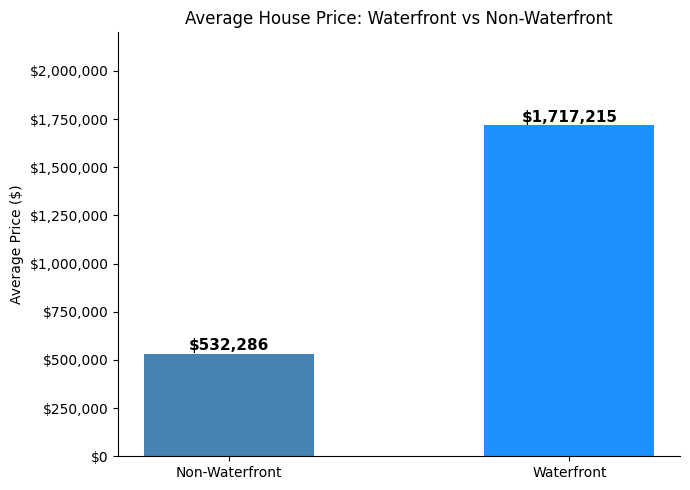

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

categories = ['Non-Waterfront', 'Waterfront']
avg_prices = [non_waterfront_prices.mean(), waterfront_prices.mean()]
colors = ['steelblue', 'dodgerblue']

bars = ax.bar(categories, avg_prices, color=colors, width=0.5)

# Add price labels on top of bars
for bar, price in zip(bars, avg_prices):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
            f'${price:,.0f}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Average House Price: Waterfront vs Non-Waterfront')
ax.set_ylabel('Average Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(0, 2_200_000)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('images/h1_waterfront_bar.png', dpi=150)
plt.show()

## H1: Waterfront vs Non-Waterfront Prices

The boxplot clearly confirms H1. Waterfront properties have a median price 
of ~$1.7M compared to ~$532K for non-waterfront homes — a 3.2x price premium. 
The interquartile range of waterfront homes sits entirely above the non-waterfront 
distribution, confirming that waterfront access is a strong price driver in King County.

**Insight for Jennifer:** Waterfront properties are significantly more expensive, 
but they also hold strong resale value — a good investment for a 1-year resell strategy.

## H2: Geographic Location vs Price

**Research Question:** Does geographic location affect house grade & price?

**H2.a Hypothesis:** The higher the grade of a house, the higher the price.

**H2.b Hypothesis:** If a house is located in zipcode 98039 (Medina), 
then the price is above the county average.

**Indicators:** `zipcode`, `grade`, `price`

**Assumption:** We define a 'rich neighborhood' as zipcodes where the majority 
of houses fall in the top 10% price percentile.

In [21]:
# Average price per zipcode
avg_price_by_zip = df.groupby('zipcode')['price'].mean().sort_values(ascending=False)

# Top 10 most expensive zipcodes
print(avg_price_by_zip.head(10))

zipcode
98039   2161300.000
98004   1356523.991
98040   1194873.638
98112   1096239.007
98102    899607.673
98109    880077.752
98105    863228.943
98006    859938.554
98119    849714.810
98005    810289.696
Name: price, dtype: float64


In [22]:
# Zipcode to city name mapping (King County)
zip_to_city = {
    98039: 'Medina', 98004: 'Bellevue', 98040: 'Mercer Island',
    98112: 'Seattle', 98102: 'Seattle', 98109: 'Seattle',
    98105: 'Seattle', 98006: 'Bellevue', 98119: 'Seattle',
    98005: 'Bellevue'
}

top10 = avg_price_by_zip.head(10).reset_index()
top10.columns = ['zipcode', 'avg_price']
top10['city'] = top10['zipcode'].map(zip_to_city)
top10['label'] = top10['zipcode'].astype(str) + '\n(' + top10['city'] + ')'

print(top10[['label', 'avg_price']])

                    label   avg_price
0         98039\n(Medina) 2161300.000
1       98004\n(Bellevue) 1356523.991
2  98040\n(Mercer Island) 1194873.638
3        98112\n(Seattle) 1096239.007
4        98102\n(Seattle)  899607.673
5        98109\n(Seattle)  880077.752
6        98105\n(Seattle)  863228.943
7       98006\n(Bellevue)  859938.554
8        98119\n(Seattle)  849714.810
9       98005\n(Bellevue)  810289.696


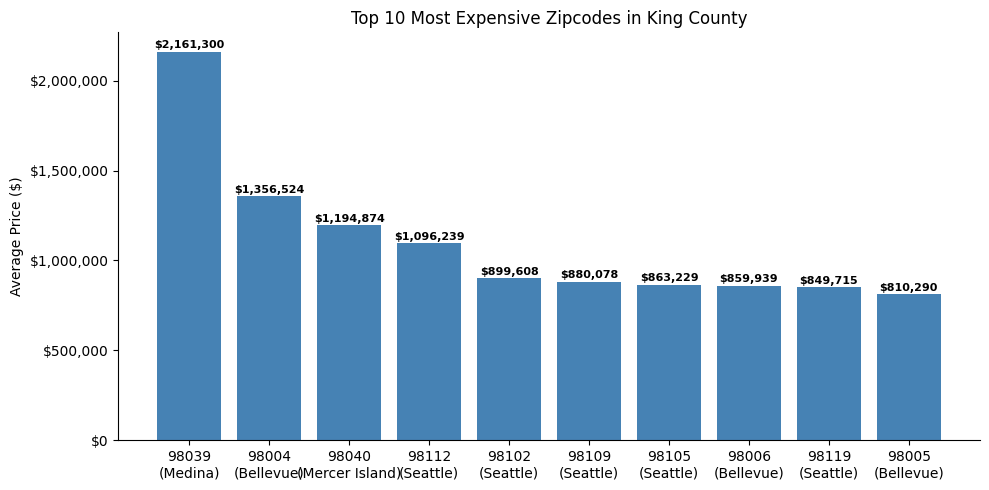

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(top10['label'], top10['avg_price'], color='steelblue')

for bar, price in zip(bars, top10['avg_price']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
            f'${price:,.0f}', ha='center', fontsize=8, fontweight='bold')

ax.set_title('Top 10 Most Expensive Zipcodes in King County')
ax.set_ylabel('Average Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('images/h2_top10_zipcodes.png', dpi=150)
plt.show()

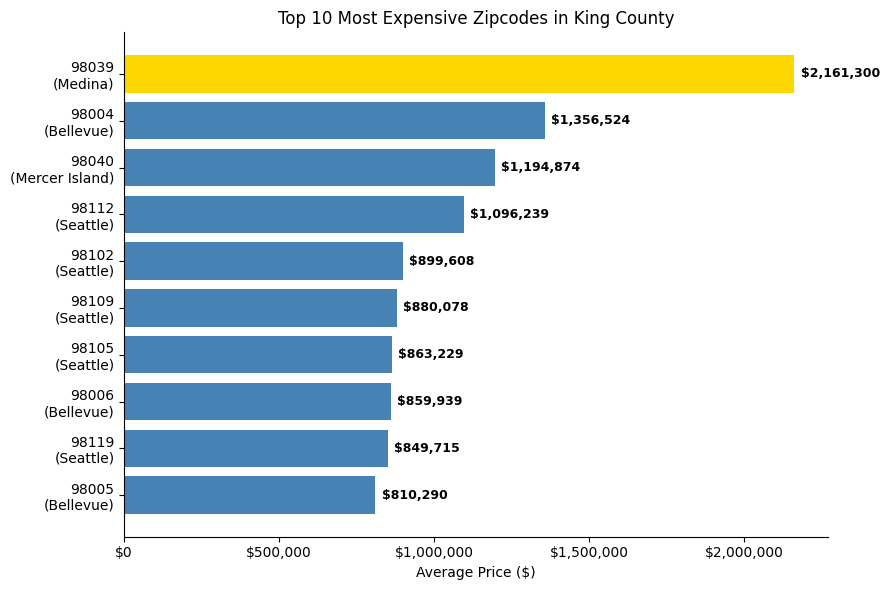

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['gold' if z == 98039 else 'steelblue' for z in top10['zipcode']]

ax.barh(top10['label'], top10['avg_price'], color=colors)

for i, price in enumerate(top10['avg_price']):
    ax.text(price + 20000, i, f'${price:,.0f}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Top 10 Most Expensive Zipcodes in King County')
ax.set_xlabel('Average Price ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('images/h2_top10_zipcodes_horizontal.png', dpi=150)
plt.show()

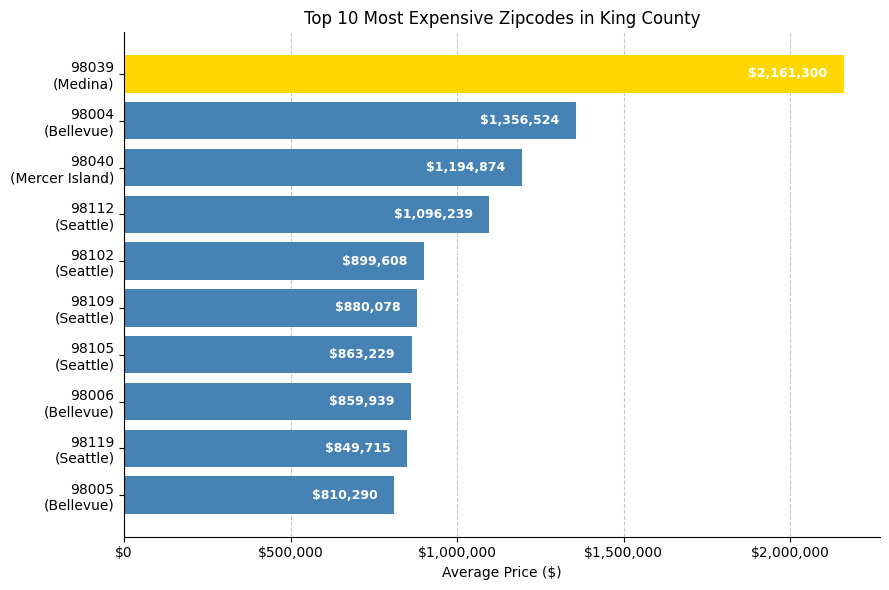

In [25]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['gold' if z == 98039 else 'steelblue' for z in top10['zipcode']]

ax.barh(top10['label'], top10['avg_price'], color=colors)

# Add value labels on bars
for i, price in enumerate(top10['avg_price']):
    ax.text(price - 50000, i, f'${price:,.0f}', va='center', ha='right', 
            fontsize=9, fontweight='bold', color='white')

ax.set_title('Top 10 Most Expensive Zipcodes in King County')
ax.set_xlabel('Average Price ($)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.invert_yaxis()

# Add grid
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('images/h2_top10_zipcodes_horizontal.png', dpi=150)
plt.show()

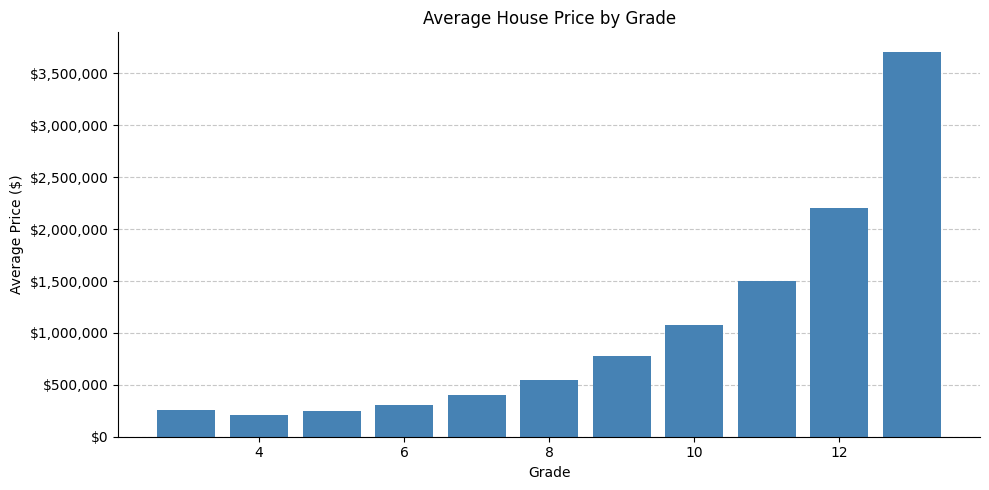

In [26]:
# H2.a: The higher the grade, the higher the price

avg_price_by_grade = df.groupby('grade')['price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(avg_price_by_grade['grade'], avg_price_by_grade['price'], color='steelblue')

ax.set_title('Average House Price by Grade')
ax.set_xlabel('Grade')
ax.set_ylabel('Average Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.grid(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('images/h2_price_by_grade.png', dpi=150)
plt.show()

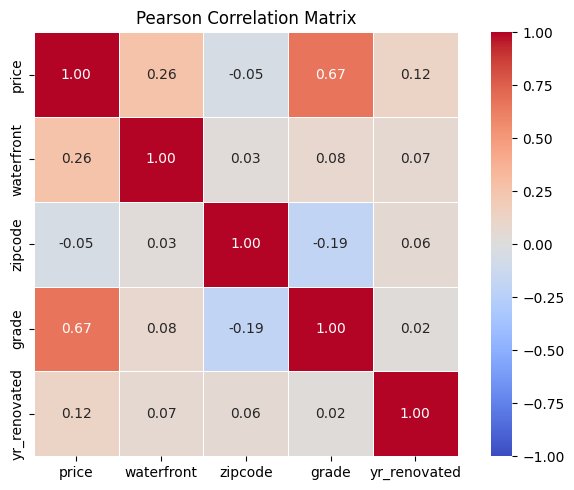

In [27]:
cols = ['price', 'waterfront', 'zipcode', 'grade', 'yr_renovated']
corr = df[cols].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)

ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

In [28]:
correlation = df['grade'].corr(df['price'])
print(f"Correlation between grade and price: {correlation:.2f}")

Correlation between grade and price: 0.67


## H2.a: Grade vs Price

The correlation between grade and price is **0.67**, indicating a strong positive 
relationship. Higher-graded houses consistently command higher prices across King County.

**Insight for Jennifer:** Targeting grade 11+ properties ensures both prestige 
and strong resale value within her 1-year timeline.

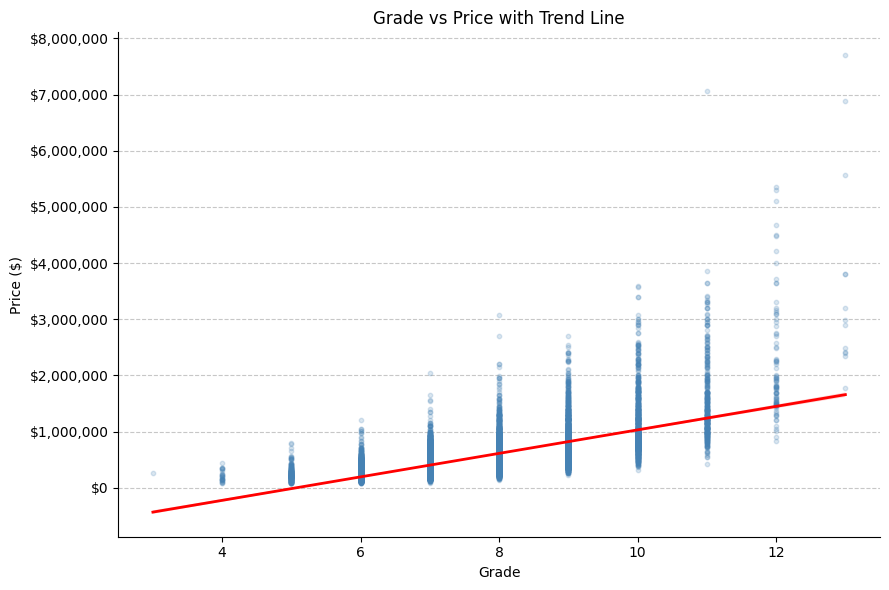

In [29]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 6))

sns.regplot(x='grade', y='price', data=df,
            scatter_kws={'alpha': 0.2, 's': 10, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2},
            ax=ax)

ax.set_title('Grade vs Price with Trend Line')
ax.set_xlabel('Grade')
ax.set_ylabel('Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('images/h2a_grade_regplot.png', dpi=150)
plt.show()

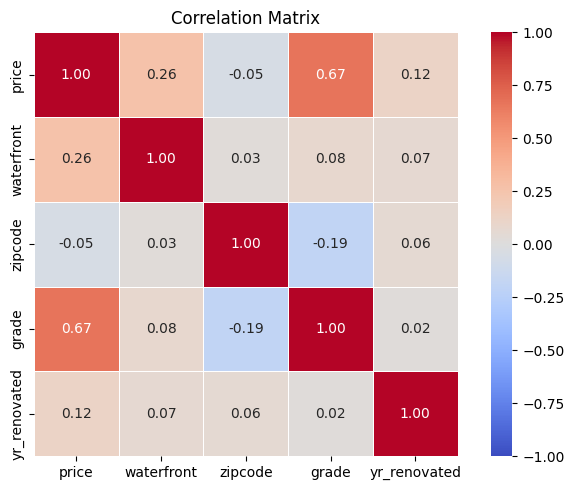

In [30]:
cols = ['price', 'waterfront', 'zipcode', 'grade', 'yr_renovated']
corr = df[cols].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)

ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('images/Correlation_matrix.png', dpi=150)
plt.show()

In [31]:
from scipy import stats

# Group prices by zipcode
groups = [group['price'].values for _, group in df.groupby('zipcode')]

# One-way ANOVA test
f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("✅ Zipcode has a statistically significant effect on price")
else:
    print("❌ No significant effect found")

F-statistic: 214.36
P-value: 0.000000
✅ Zipcode has a statistically significant effect on price


## H2: Zipcode vs Price — ANOVA Test

Since zipcode is a categorical variable, Pearson correlation is not the appropriate 
measure. We used a one-way ANOVA test instead.

- F-statistic: 214.36
- P-value: ≈ 0.000000

The extremely low p-value confirms that zipcode has a **statistically significant 
effect on house prices** in King County. Location is not just a number — it's 
one of the strongest price drivers in the dataset.

In [32]:
# H2.b: Is zipcode 98039 (Medina) above the county average?

county_avg = df['price'].mean()
medina_avg = df[df['zipcode'] == 98039]['price'].mean()

print(f"County average price: ${county_avg:,.0f}")
print(f"Medina (98039) avg price: ${medina_avg:,.0f}")
print(f"Medina is {medina_avg / county_avg:.1f}x above county average")

County average price: $540,297
Medina (98039) avg price: $2,161,300
Medina is 4.0x above county average


In [33]:

import folium
from folium.plugins import HeatMap


luxury_df = df[df["price"] > df["price"].quantile(0.90)]

# -----------------------------------
# CREATE BASE MAP
# -----------------------------------
m = folium.Map(
    location=[47.55, -122.25],   # King County center
    zoom_start=9,
    tiles="OpenStreetMap"
)

# -----------------------------------
# PREPARE HEATMAP DATA
# lat, long, intensity(price)
# -----------------------------------
heat_data = [
    [row["lat"], row["long"], row["price"]]
    for _, row in luxury_df.iterrows()
]

# -----------------------------------
# ADD HEATMAP
# -----------------------------------
HeatMap(
    heat_data,
    radius=18,
    blur=25,
    max_zoom=10,
    min_opacity=0.35
).add_to(m)

# -----------------------------------
# SAVE MAP
# -----------------------------------
m.save("images/luxury_heatmap.html")

# show in notebook
m

In [34]:
# Medina houses
medina_df = df[df["zipcode"] == 98039]

# Overall price percentile rank of Medina average
medina_avg = medina_df["price"].mean()

percentile = (
    (df["price"] < medina_avg).mean()
) * 100

print(f"Medina average price: ${medina_avg:,.0f}")
print(f"Medina is more expensive than {percentile:.1f}% of all houses.")

Medina average price: $2,161,300
Medina is more expensive than 99.2% of all houses.


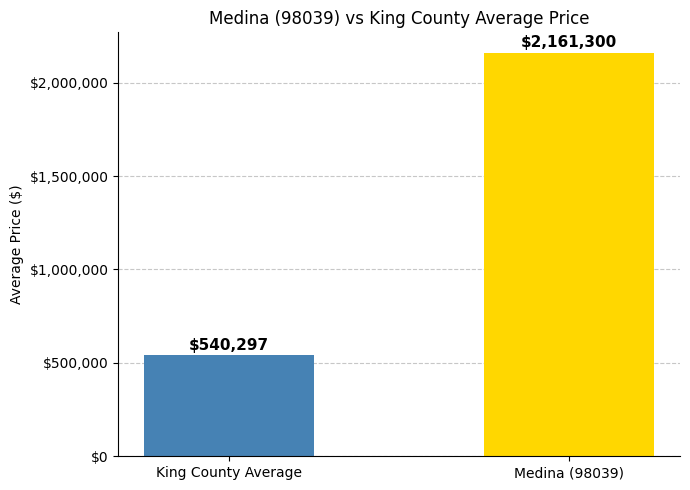

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))

categories = ['King County Average', 'Medina (98039)']
prices = [county_avg, medina_avg]
colors = ['steelblue', 'gold']

bars = ax.bar(categories, prices, color=colors, width=0.5)

for bar, price in zip(bars, prices):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30000,
            f'${price:,.0f}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Medina (98039) vs King County Average Price')
ax.set_ylabel('Average Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('images/h2b_medina_vs_county.png', dpi=150)
plt.show()

In [36]:
county_avg = df['price'].mean()          # $540,297
medina_avg = df[df['zipcode'] == 98039]['price'].mean()  # $2,161,300

print(medina_avg / county_avg)  # = 4.0

4.000210451043478


## H2.b: Medina (98039) vs King County Average

Medina (zipcode 98039) has an average price of $2,161,300 — exactly **4x above 
the King County average** of $540,297, making it the most expensive neighborhood 
in the dataset.

**Insight for Jennifer:** Medina is the prime location for high-budget buyers 
seeking prestige and strong resale value. As home to some of the wealthiest 
residents in the US, it perfectly matches her "show-off" criteria.

## H3: Renovation Status vs Price

**Research Question:** Does renovation status affect resale value?

**H3.a Hypothesis:** The more recently a house was renovated, 
the higher the sale price.

**H3.b Hypothesis:** If a house was renovated after 2000, then the price 
is higher than never-renovated homes.

**Indicators:** `yr_renovated`, `price`

In [37]:
print(df['renovation_status'].value_counts())

KeyError: 'renovation_status'

In [ ]:
# Create renovation categories
df['renovation_status'] = 'Never Renovated'
df.loc[df['yr_renovated'] > 2000, 'renovation_status'] = 'Renovated After 2000'
df.loc[(df['yr_renovated'] > 0) & (df['yr_renovated'] <= 2000), 'renovation_status'] = 'Renovated Before 2000'
avg_price_by_reno = df.groupby('renovation_status')['price'].mean().reset_index()

order = ['Never Renovated', 'Renovated Before 2000', 'Renovated After 2000']
avg_price_by_reno['renovation_status'] = pd.Categorical(
    avg_price_by_reno['renovation_status'], categories=order, ordered=True)
avg_price_by_reno = avg_price_by_reno.sort_values('renovation_status').reset_index(drop=True)

print(avg_price_by_reno)

       renovation_status      price
0        Never Renovated 532140.320
1  Renovated Before 2000 711246.198
2   Renovated After 2000 833805.731


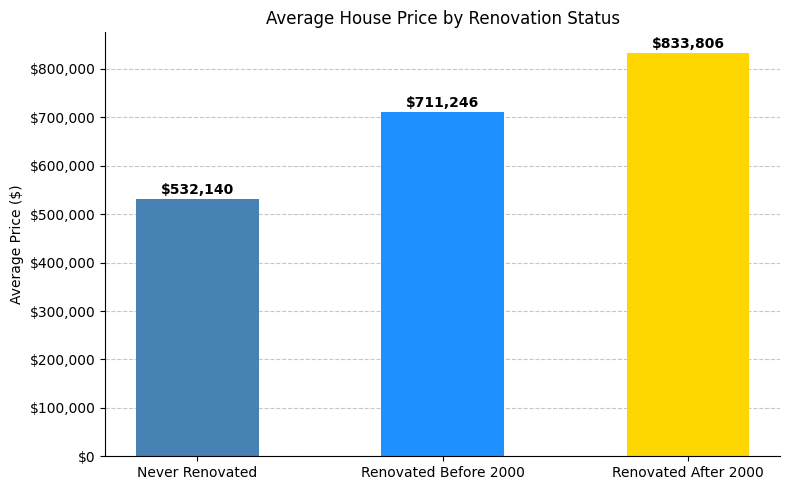

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['steelblue', 'dodgerblue', 'gold']
bars = ax.bar(avg_price_by_reno['renovation_status'], 
              avg_price_by_reno['price'], 
              color=colors, width=0.5)

for bar, price in zip(bars, avg_price_by_reno['price']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
            f'${price:,.0f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Average House Price by Renovation Status')
ax.set_ylabel('Average Price ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('images/h3_renovation_prices.png', dpi=150)
plt.show()

## H3: Renovation Status vs Price

Houses renovated after 2000 have an average price of **$833,806** — **57% higher** 
than never-renovated homes ($532,140). Even homes renovated before 2000 show a 
significant premium, with an average price of **$711,246**.

The analysis suggests that renovated houses tend to have higher prices. However, 
other variables such as location, house size, and number of rooms may also influence 
pricing. Future analyses could use regression models to control for these factors.

**Insight for Jennifer:** A recently renovated waterfront property in Medina is 
likely to command the highest resale value. If the target property is not renovated, 
completing renovations after purchase could significantly increase the potential 
resale price within her 1-year investment timeline.

In [38]:
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month_name()
monthly_price = df.groupby("month")["price"].mean()
print(monthly_price)

month
April       562215.615
August      536655.212
December    524799.902
February    508520.051
January     525963.252
July        544892.161
June        557534.318
March       544057.683
May         550849.747
November    522359.903
October     539439.447
September   529723.518
Name: price, dtype: float64


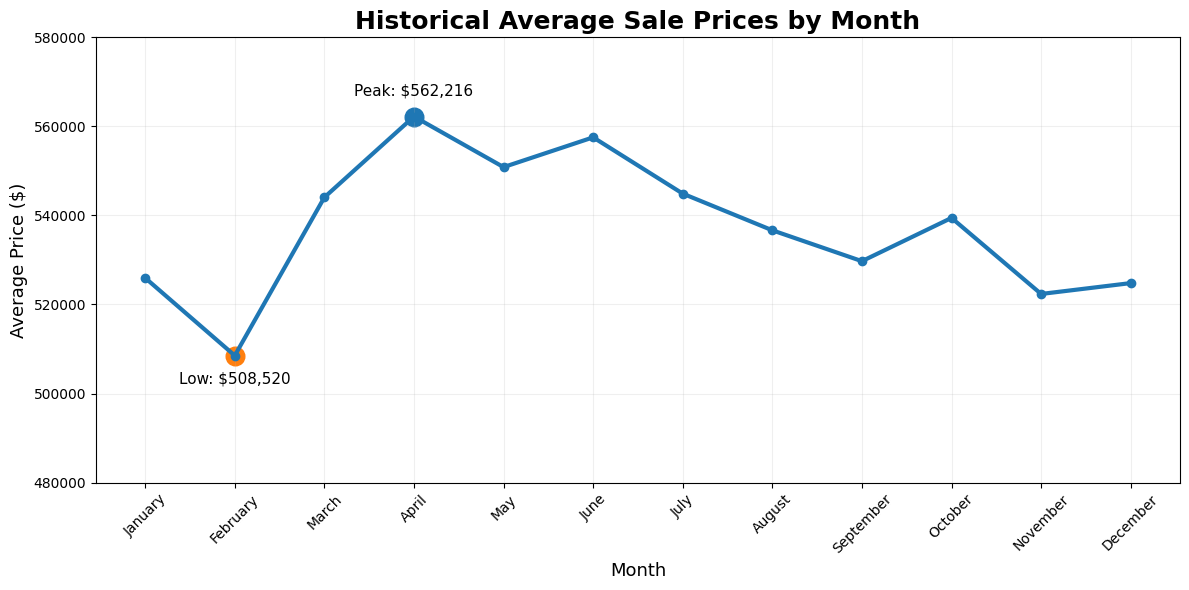

In [39]:


# ordered months
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_price = (
    df.groupby("month")["price"]
    .mean()
    .reindex(month_order)
)

# -----------------------------------
# PLOT
# -----------------------------------
plt.figure(figsize=(12,6))

plt.plot(
    monthly_price.index,
    monthly_price.values,
    marker="o",
    linewidth=3
)

# Highlight highest month
max_month = monthly_price.idxmax()
max_value = monthly_price.max()

plt.scatter(max_month, max_value, s=180)
# Lowest month
min_month = monthly_price.idxmin()
min_value = monthly_price.min()

plt.scatter(min_month, min_value, s=180)

plt.annotate(
    f"Low: ${min_value:,.0f}",
    xy=(min_month, min_value),
    xytext=(0,-20),
    textcoords="offset points",
    ha="center",
    fontsize=11
)
# Labels
plt.title(
    "Historical Average Sale Prices by Month",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Month", fontsize=13)
plt.ylabel("Average Price ($)", fontsize=13)

# Grid
plt.grid(alpha=0.3)

# Rotate labels
plt.xticks(rotation=45)

# Annotate peak
plt.annotate(
    f"Peak: ${max_value:,.0f}",
    xy=(max_month, max_value),
    xytext=(0,15),
    textcoords="offset points",
    ha="center",
    fontsize=11
)
plt.ylim(480000, 580000)
plt.grid(alpha=0.2)
xytext=(0,10)

plt.tight_layout()
plt.savefig('images/Average_house_prices.png', dpi=150)
plt.show()

## Conclusions & Recommendations for Jennifer

1. **Buy waterfront** — 3.2x price premium, strong resale signal
2. **Target Medina (98039)** — 4x above county average, most prestigious zip
3. **Prioritize grade 11+** — strong correlation (0.67) with price
4. **Recently renovated preferred** — $301K premium over never-renovated homes

**Best scenario:** Waterfront + Medina + Grade 11+ + Post-2000 renovation